In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import glob, re
from collections import defaultdict
import scipy.stats as stats
from mne.stats import permutation_cluster_1samp_test
import warnings
warnings.filterwarnings("ignore", message="No clusters found", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="Provided stat_fun", category=RuntimeWarning)

In [2]:
# Config
CACHE_DIR = '/home/dilay/project2/tw/results/micheal_fft'
SAVE_ROOT = '/home/dilay/project2/tw/results/figs/micheal_single'
alpha_level = 0.05
BL0, BL1    = -0.75, -0.25
BL_CORRECT  = False
RT_REMOVE   = True
MEASURES    = ['fw', 'bw']
MAX_RT      = 1.5  # trial-validity RT cutoff (late_rt <= MAX_RT)

# Import all plotting functions from the py module
import sys
sys.path.insert(0, '/home/dilay/project2/tw/travelling_waves/tw/fft/micheal')
import micheal_plot_funcs as twplot
twplot.SAVE_ROOT = SAVE_ROOT
twplot.MAX_RT = MAX_RT
twplot.RT_REMOVE = RT_REMOVE

from  micheal_plot_funcs import (
    compute_fast_slow, plot_fast_slow,
    plot_tf_maps, 
    plot_band_timeseries, 
     plot_all_lines_measures,
    print_trial_summary,
    FLIPPED_LINE_NAMES, resolve_line_idx,
)

# Line selection for cue/hand-aligned plots.
# After alignment: C1-C5 are contralateral lines, I1-I5 are ipsilateral lines, M is midline.
# CONTRA_LINES = ['C5', 'C4','C3', 'C2', 'C1']
# IPSI_LINES   = ['I1', 'I2', 'I3','I4','I5']
CONTRA_LINES = ['C5','C2']
IPSI_LINES   = ['I5','I2']
MID_LINES    = ['M']
LINE_KW = dict(contra_idx=CONTRA_LINES, ipsi_idx=IPSI_LINES, mid_idx=MID_LINES)
print('Aligned line order:', FLIPPED_LINE_NAMES)
print('Using line indices:', {k: resolve_line_idx(v, []) for k, v in LINE_KW.items()})


Aligned line order: ['C5', 'C4', 'C3', 'C2', 'C1', 'M', 'I1', 'I2', 'I3', 'I4', 'I5']
Using line indices: {'contra_idx': [0, 3], 'ipsi_idx': [10, 7], 'mid_idx': [5]}


In [3]:
from pathlib import Path

by_subj, subj_ids = twplot.load_results(Path(CACHE_DIR))
print(f"Subjects: {subj_ids}")
print_trial_summary(by_subj, subj_ids, trial_filter=None, max_rt=MAX_RT)

Subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Trial summary (per subject, sessions pooled; all percentages are out of the raw total; total_removed% uses the union of bad and RT exclusions):
subj	total	kept%	bad_removed%	rt_removed%	overlap%	total_removed%	early_rt_mean	late_rt_mean
1	1728	87.85%	10.94%	4.86%	3.65%	12.15%	0.458	0.471
2	1727	92.65%	4.52%	3.94%	1.10%	7.35%	0.563	0.551
3	1728	77.89%	21.64%	5.03%	4.57%	22.11%	0.491	0.563
4	1728	90.91%	8.04%	2.26%	1.22%	9.09%	0.501	0.539
5	1726	89.75%	8.63%	4.23%	2.61%	10.25%	0.533	0.561
6	1728	87.27%	11.57%	3.30%	2.14%	12.73%	0.541	0.555
7	1727	87.09%	10.83%	6.43%	4.34%	12.91%	0.582	0.599
8	1728	84.95%	12.73%	4.40%	2.08%	15.05%	0.505	0.475
9	1728	82.06%	14.41%	8.85%	5.32%	17.94%	0.541	0.575
10	1728	95.43%	4.40%	0.41%	0.23%	4.57%	0.364	0.392
11	1728	89.06%	10.88%	0.64%	0.58%	10.94%	0.415	0.433
12	1727	92.13%	7.76%	0.23%	0.12%	7.87%	0.383	0.418
13	1728	93.29%	5.44%	2.43%	1.16%	6.71%	0.557	0.593
14	1728	77.43%	2

## Fast / Slow RT Analysis (commented out)

In [4]:
# MODE    = 'hand'
# RT_TYPE = 'early'

# freq_bands = [(2, 6), (8, 12), (14, 30)]

# for fmin, fmax in freq_bands:
#     result = compute_fast_slow(
#         by_subj, subj_ids,
#         mode=MODE,
#         fmin=fmin, fmax=fmax,
#         bl0=BL0, bl1=BL1,
#         rt_type=RT_TYPE,
#         baseline_correct=BL_CORRECT,
#         trial_filter='all',
#         max_rt=MAX_RT,
#     )
#     plot_fast_slow(*result, mode=MODE, fmin=fmin, fmax=fmax, rt_type=RT_TYPE)

In [5]:
# MODE    = 'hand'
# RT_TYPE = 'late'

# freq_bands = [(2, 6), (8, 12), (14, 30)]

# for fmin, fmax in freq_bands:
#     result = compute_fast_slow(
#         by_subj, subj_ids,
#         mode=MODE,
#         fmin=fmin, fmax=fmax,
#         bl0=BL0, bl1=BL1,
#         rt_type=RT_TYPE,
#         baseline_correct=BL_CORRECT,
#         trial_filter='all',
#         max_rt=MAX_RT,
#     )
#     plot_fast_slow(*result, mode=MODE, fmin=fmin, fmax=fmax, rt_type=RT_TYPE)

In [6]:
# MODE    = 'cue'
# RT_TYPE = 'early'

# freq_bands = [(2, 6), (8, 12), (14, 22), (24, 30)]

# for fmin, fmax in freq_bands:
#     result = compute_fast_slow(
#         by_subj, subj_ids,
#         mode=MODE,
#         fmin=fmin, fmax=fmax,
#         bl0=BL0, bl1=BL1,
#         rt_type=RT_TYPE,
#     )
#     plot_fast_slow(*result, mode=MODE, fmin=fmin, fmax=fmax, rt_type=RT_TYPE)

In [7]:
# MODE    = 'cue'
# RT_TYPE = 'late'

# freq_bands = [(2, 6), (8, 12), (14, 22), (24, 30)]

# for fmin, fmax in freq_bands:
#     result = compute_fast_slow(
#         by_subj, subj_ids,
#         mode=MODE,
#         fmin=fmin, fmax=fmax,
#         bl0=BL0, bl1=BL1,
#         rt_type=RT_TYPE,
#     )
#     plot_fast_slow(*result, mode=MODE, fmin=fmin, fmax=fmax, rt_type=RT_TYPE)

## TF Maps

FW (CONTRA) -- Cue-Location 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
FW (IPSI) -- Cue-Location 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
FW (MID) -- Cue-Location 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/fw_cue_tf_contra-ipsi-mid.png


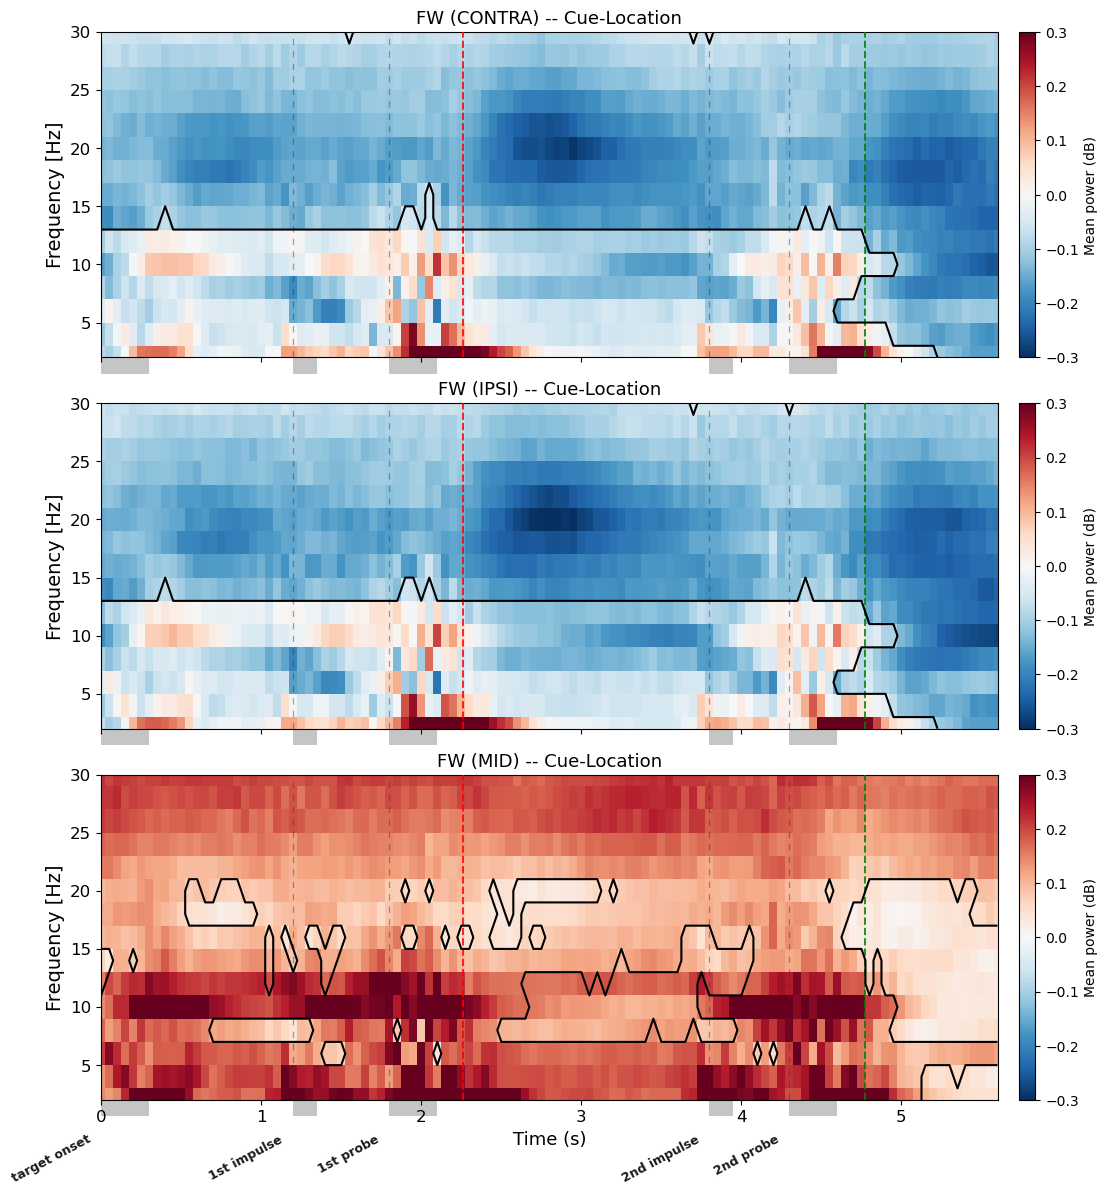

FW (CONTRA-IPSI) -- Cue-Location 2D clusters:
8.00-18.00 Hz, 2.50-3.15 s, p=0.006 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/fw_cue_tf.png


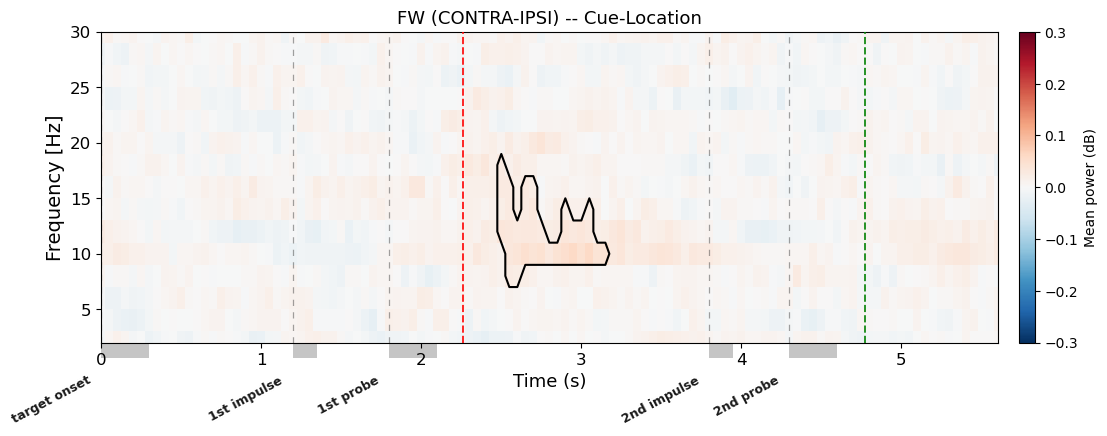

BW (CONTRA) -- Cue-Location 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
BW (IPSI) -- Cue-Location 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
BW (MID) -- Cue-Location 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/bw_cue_tf_contra-ipsi-mid.png


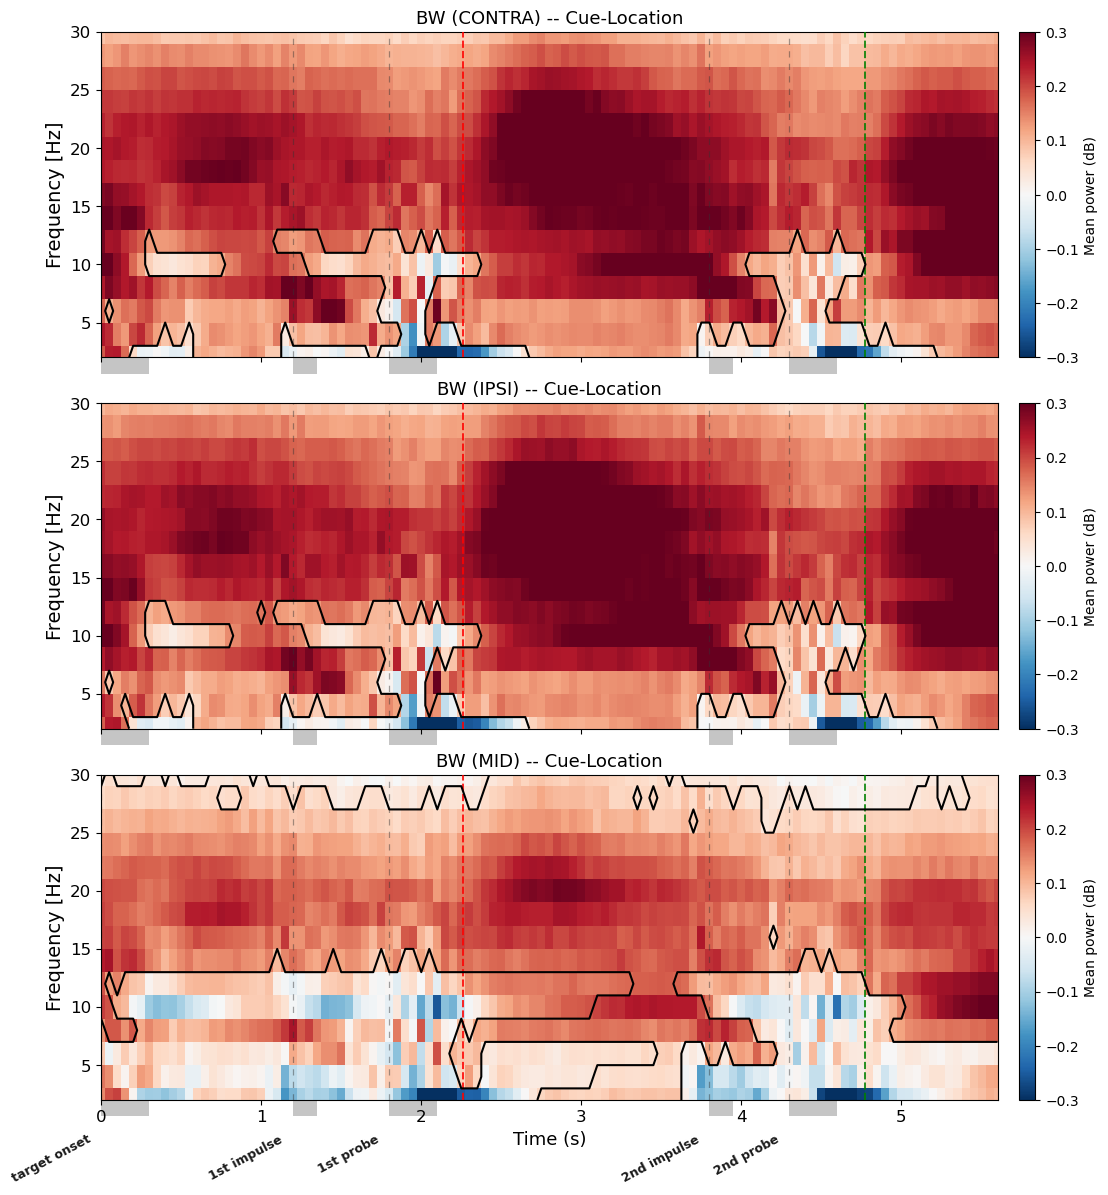

BW (CONTRA-IPSI) -- Cue-Location 2D clusters:
10.00-20.00 Hz, 2.20-3.05 s, p=0.003 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/bw_cue_tf.png


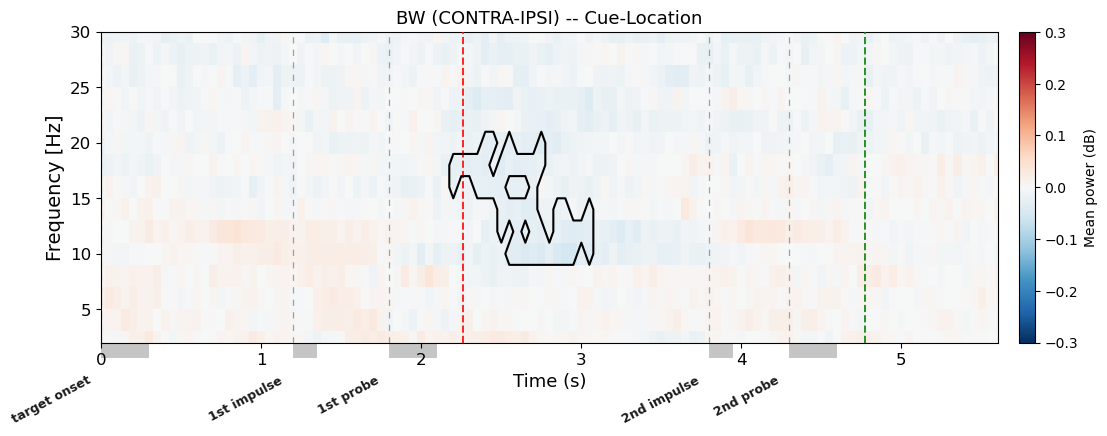

({'fw': {'diff': (<Figure size 1200x450 with 2 Axes>,
    <Axes: title={'center': 'FW (CONTRA-IPSI) -- Cue-Location'}, xlabel='Time (s)', ylabel='Frequency [Hz]'>,
    [{'p': 0.4686,
      'significant': False,
      'freq_start_idx': 0,
      'freq_end_idx': 0,
      'time_start_idx': 70,
      'time_end_idx': 75},
     {'p': 1.0,
      'significant': False,
      'freq_start_idx': 1,
      'freq_end_idx': 1,
      'time_start_idx': 26,
      'time_end_idx': 26},
     {'p': 1.0,
      'significant': False,
      'freq_start_idx': 2,
      'freq_end_idx': 2,
      'time_start_idx': 10,
      'time_end_idx': 10},
     {'p': 1.0,
      'significant': False,
      'freq_start_idx': 2,
      'freq_end_idx': 2,
      'time_start_idx': 15,
      'time_end_idx': 15},
     {'p': 1.0,
      'significant': False,
      'freq_start_idx': 2,
      'freq_end_idx': 2,
      'time_start_idx': 21,
      'time_end_idx': 21},
     {'p': 1.0,
      'significant': False,
      'freq_start_idx': 2,
      '

In [8]:
plot_tf_maps(by_subj, subj_ids, mode='cue', bl0=-0.75, bl1=-0.25, t_stop=5.6, fmax=30, baseline_correct=BL_CORRECT, measure=MEASURES,exclude_invalid_rt = RT_REMOVE, **LINE_KW)

In [9]:
# plot_tf_maps(by_subj, subj_ids, mode='cue', bl0=-0.75, bl1=-0.25, t_stop=5.6, fmax=40, measure=MEASURES, baseline_correct=BL_CORRECT, trial_filter='ipsi', **LINE_KW)

In [10]:
# plot_tf_maps(by_subj, subj_ids, mode='cue', bl0=-0.75, bl1=-0.25, t_stop=5.6, fmax=40, measure=MEASURES, baseline_correct=BL_CORRECT, trial_filter='contra', **LINE_KW)

FW (CONTRA) -- Respond-Hand (early) 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
FW (IPSI) -- Respond-Hand (early) 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
FW (MID) -- Respond-Hand (early) 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/fw_early_hand_tf_contra-ipsi-mid.png


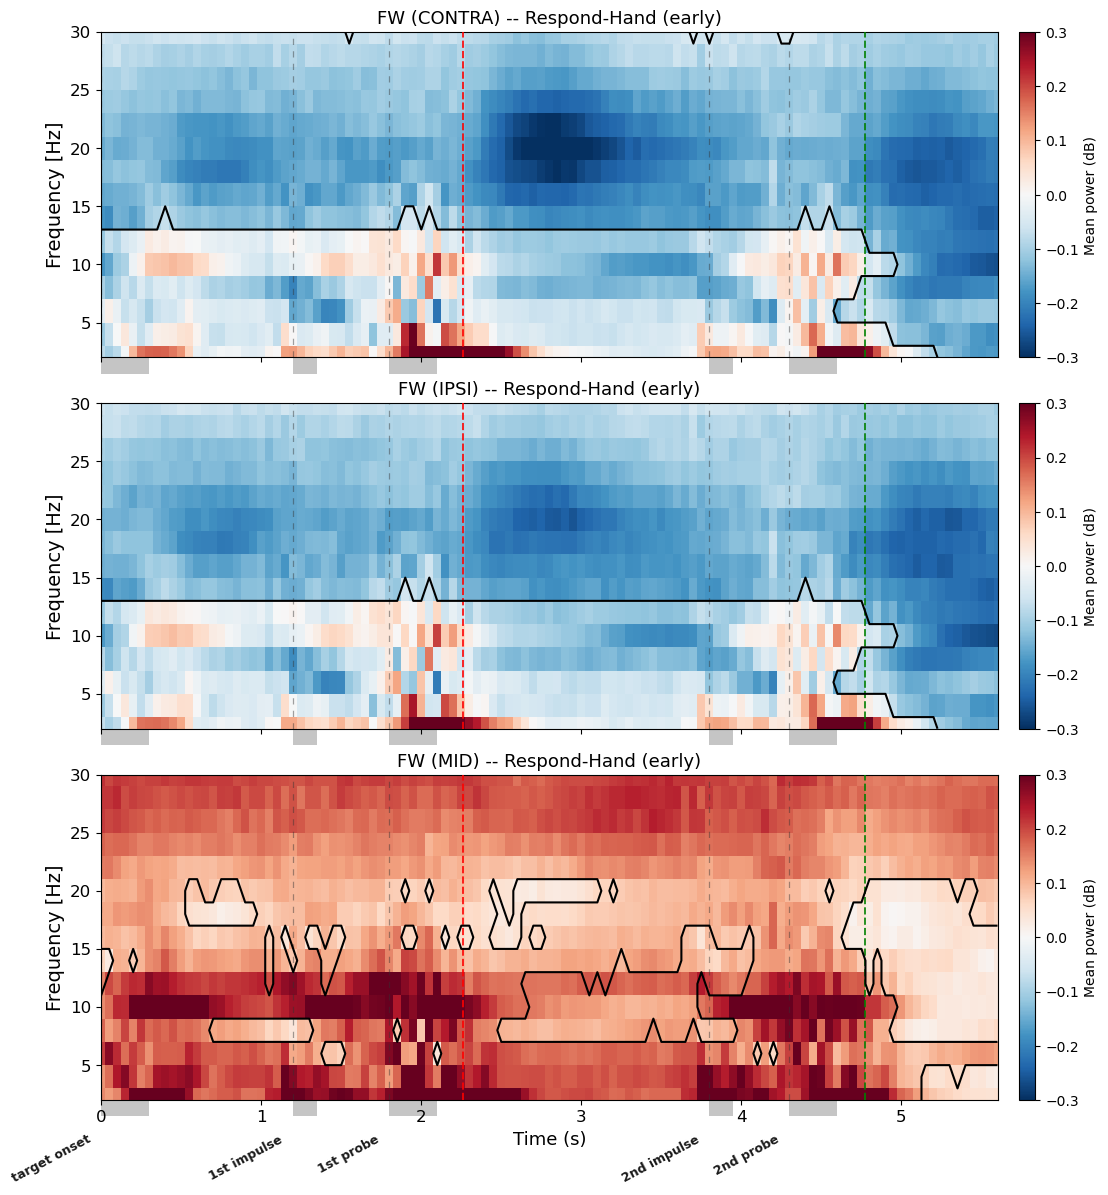

FW (CONTRA-IPSI) -- Respond-Hand (early) 2D clusters:
2.00-4.00 Hz, 1.80-2.95 s, p=0.007 (significant)
14.00-30.00 Hz, 2.45-3.95 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/fw_early_hand_tf.png


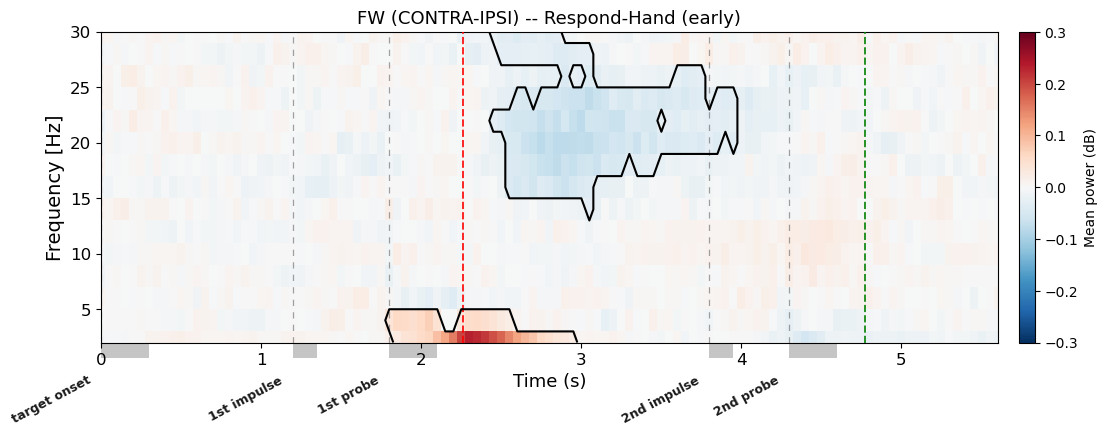

BW (CONTRA) -- Respond-Hand (early) 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
BW (IPSI) -- Respond-Hand (early) 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
BW (MID) -- Respond-Hand (early) 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/bw_early_hand_tf_contra-ipsi-mid.png


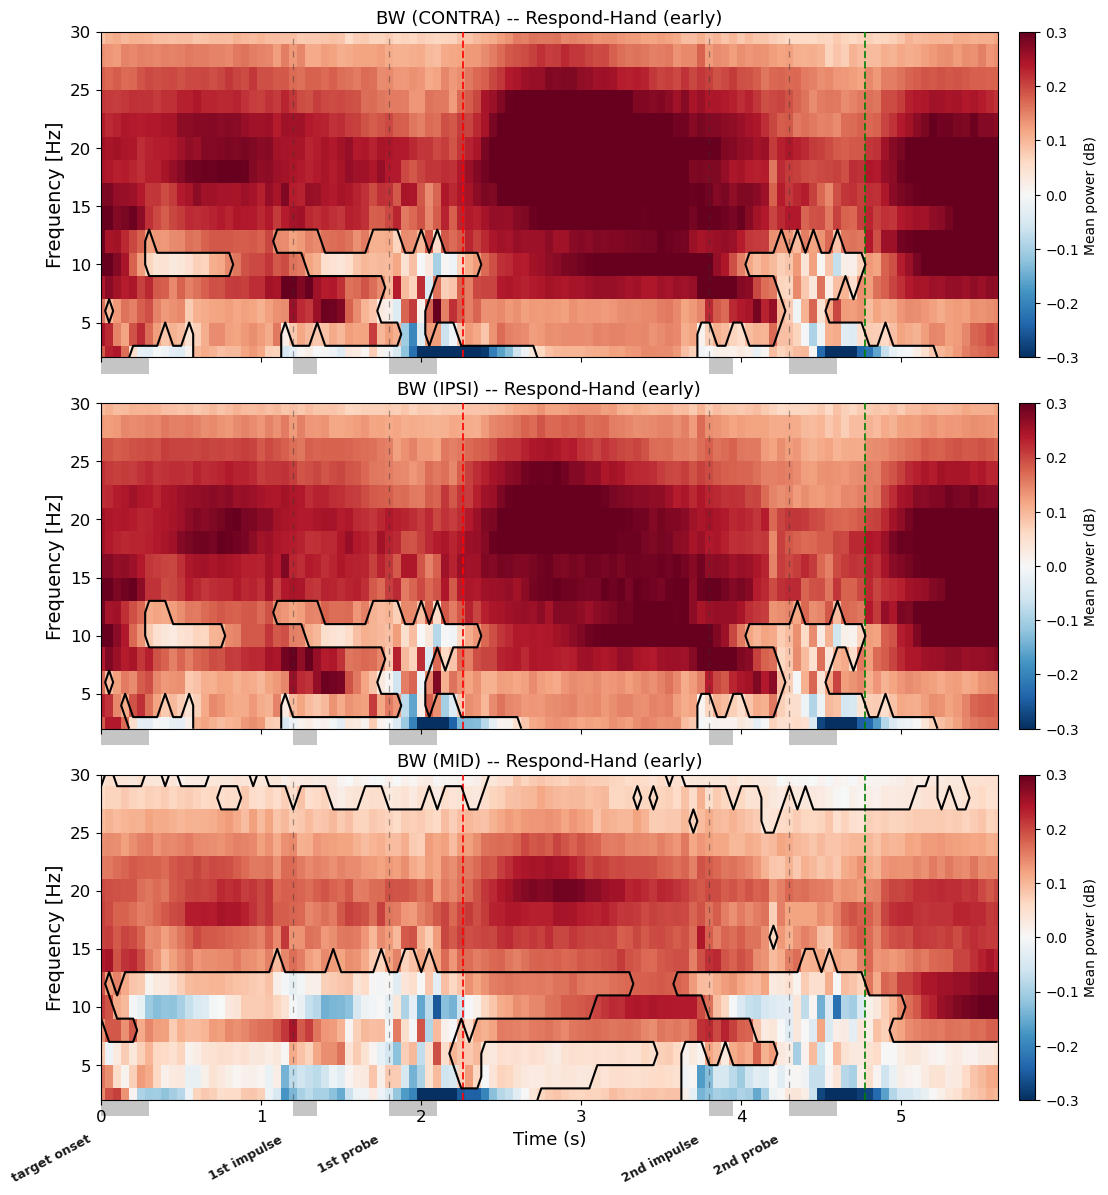

BW (CONTRA-IPSI) -- Respond-Hand (early) 2D clusters:
14.00-30.00 Hz, 2.50-4.65 s, p=0.0002 (significant)
2.00-4.00 Hz, 2.00-2.95 s, p=0.0326 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/bw_early_hand_tf.png


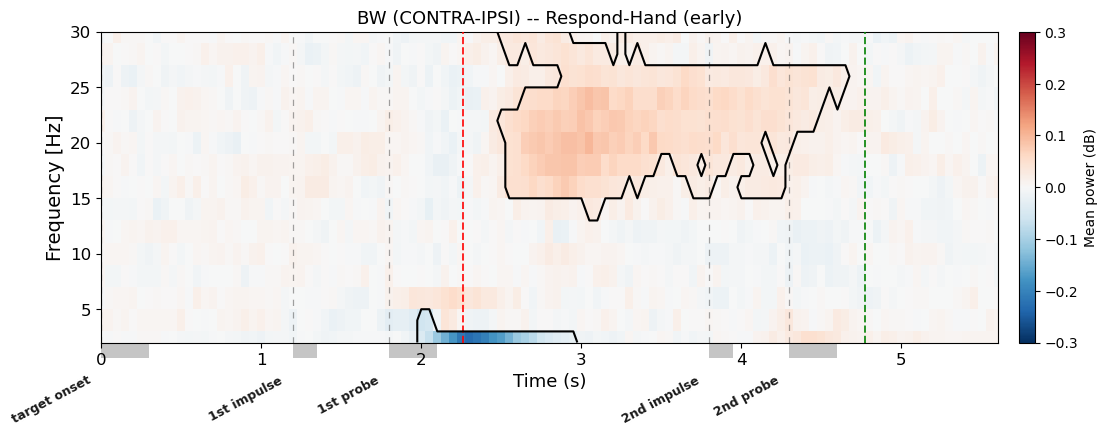

FW (CONTRA) -- Respond-Hand (late) 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
FW (IPSI) -- Respond-Hand (late) 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
FW (MID) -- Respond-Hand (late) 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/fw_late_hand_tf_contra-ipsi-mid.png


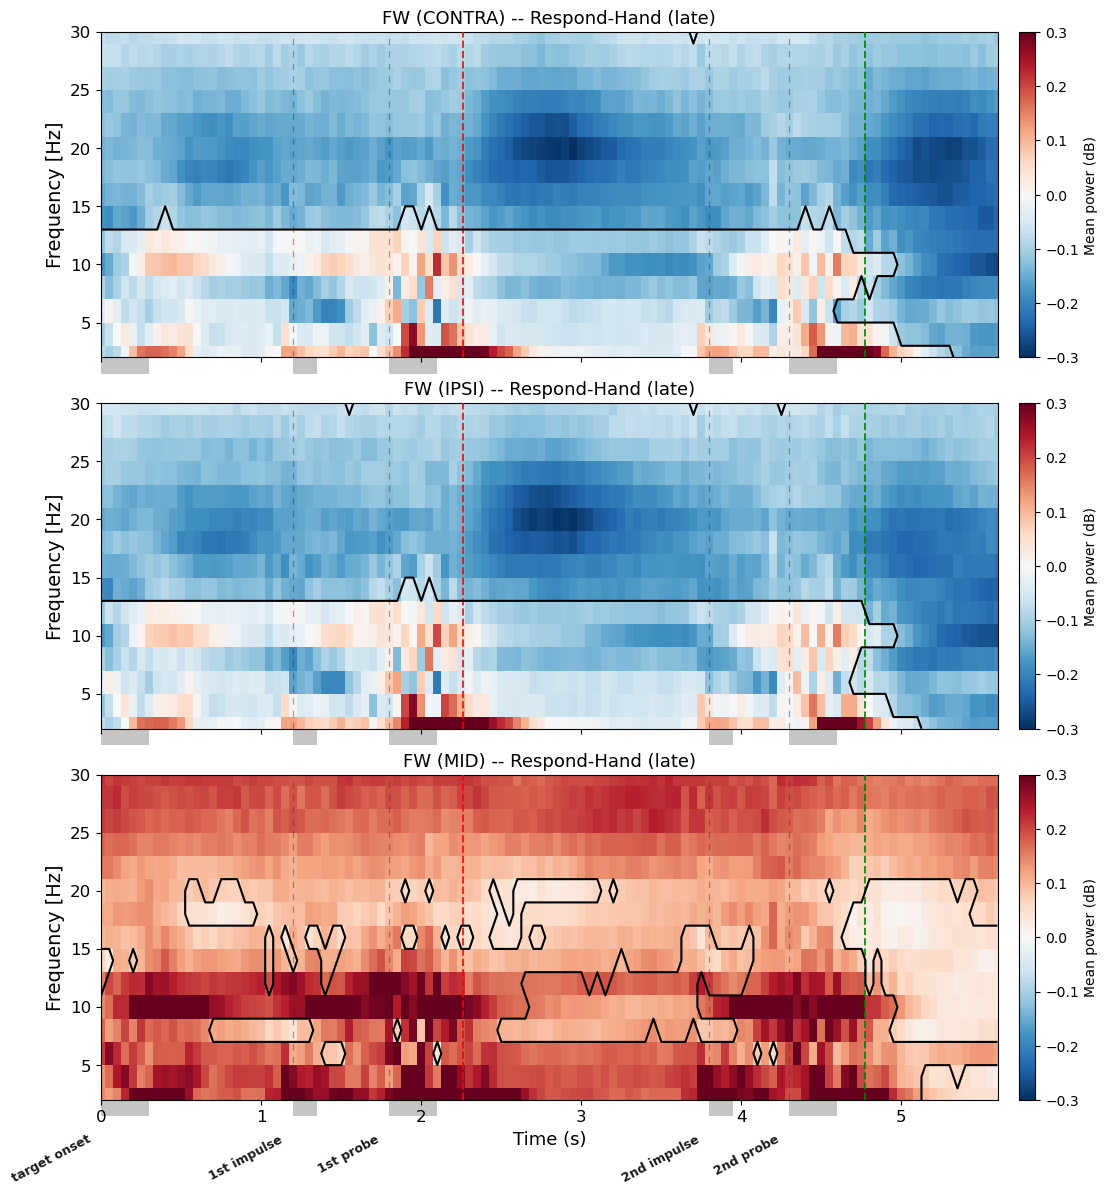

FW (CONTRA-IPSI) -- Respond-Hand (late) 2D clusters:
2.00-4.00 Hz, 4.50-5.35 s, p=0.0066 (significant)
14.00-28.00 Hz, 5.05-5.60 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/fw_late_hand_tf.png


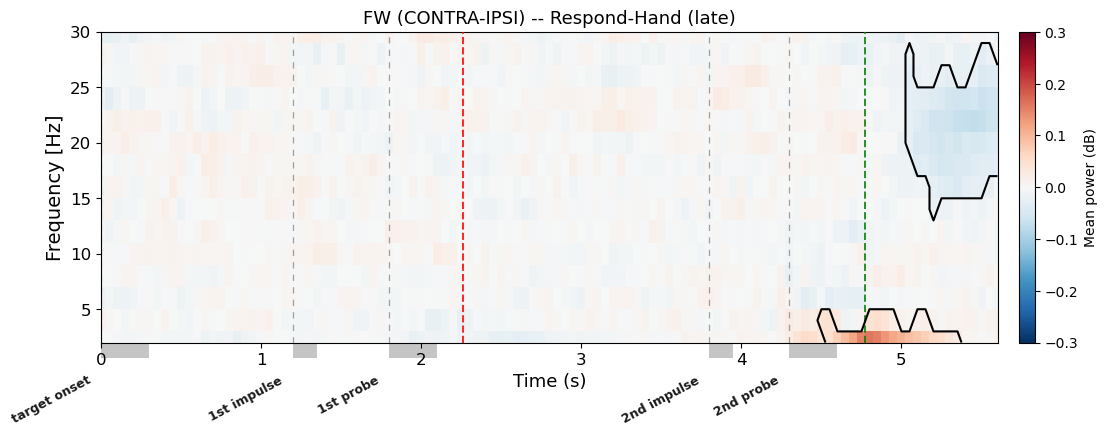

BW (CONTRA) -- Respond-Hand (late) 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
BW (IPSI) -- Respond-Hand (late) 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
BW (MID) -- Respond-Hand (late) 2D clusters:
2.00-30.00 Hz, 0.00-5.60 s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/bw_late_hand_tf_contra-ipsi-mid.png


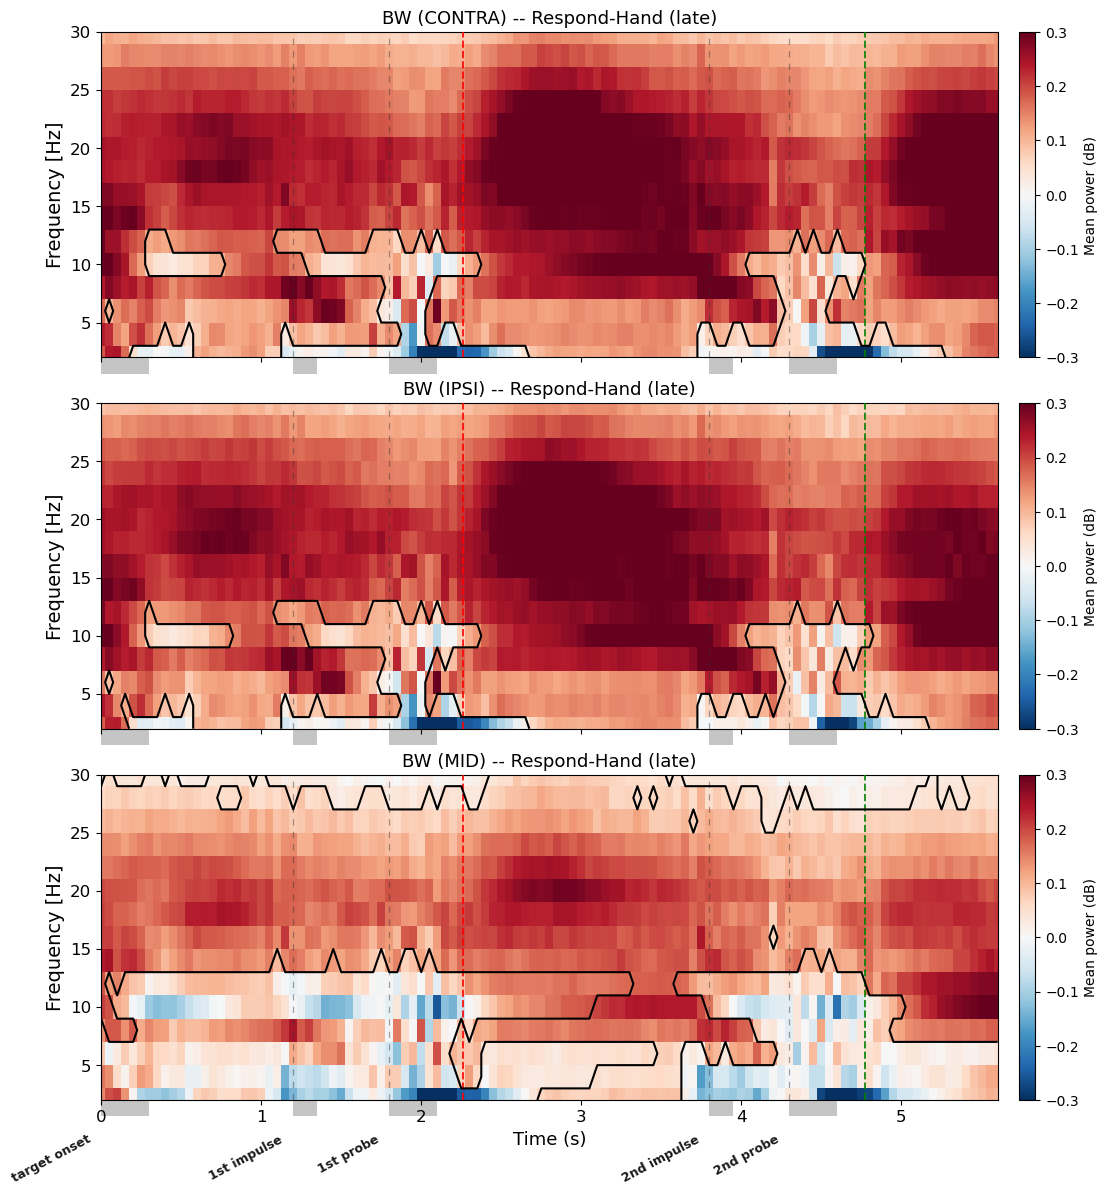

BW (CONTRA-IPSI) -- Respond-Hand (late) 2D clusters:
4.00-10.00 Hz, 4.35-5.05 s, p=0.0222 (significant)
14.00-30.00 Hz, 5.00-5.60 s, p=0.0002 (significant)
2.00-2.00 Hz, 4.55-5.30 s, p=0.0222 (significant)
20.00-26.00 Hz, 4.45-4.75 s, p=0.0424 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/bw_late_hand_tf.png


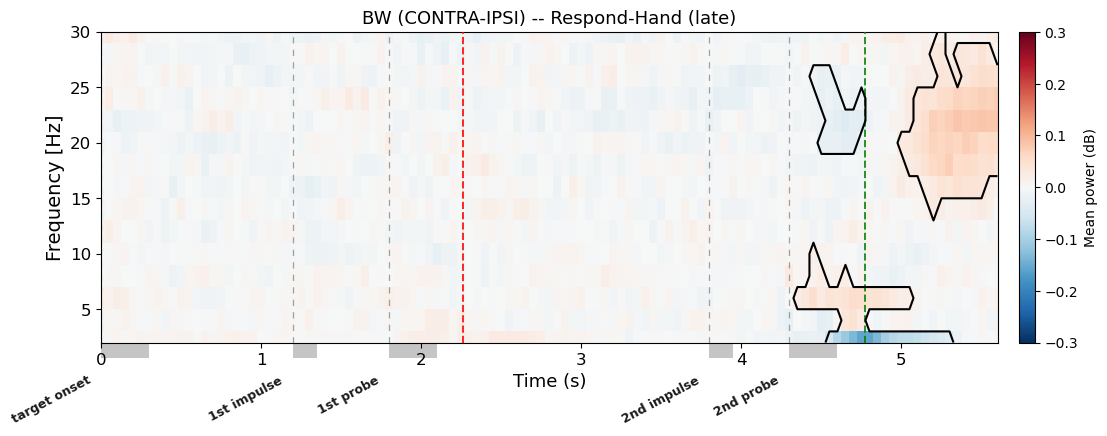

({'fw': {'diff': (<Figure size 1200x450 with 2 Axes>,
    <Axes: title={'center': 'FW (CONTRA-IPSI) -- Respond-Hand (late)'}, xlabel='Time (s)', ylabel='Frequency [Hz]'>,
    [{'p': 1.0,
      'significant': False,
      'freq_start_idx': 0,
      'freq_end_idx': 0,
      'time_start_idx': 80,
      'time_end_idx': 80},
     {'p': 0.1576,
      'significant': False,
      'freq_start_idx': 0,
      'freq_end_idx': 1,
      'time_start_idx': 86,
      'time_end_idx': 89},
     {'p': 0.0066,
      'significant': True,
      'freq_start_idx': 0,
      'freq_end_idx': 1,
      'time_start_idx': 90,
      'time_end_idx': 107},
     {'p': 1.0,
      'significant': False,
      'freq_start_idx': 1,
      'freq_end_idx': 1,
      'time_start_idx': 21,
      'time_end_idx': 21},
     {'p': 0.999,
      'significant': False,
      'freq_start_idx': 1,
      'freq_end_idx': 1,
      'time_start_idx': 71,
      'time_end_idx': 72},
     {'p': 1.0,
      'significant': False,
      'freq_start_idx'

In [11]:
plot_tf_maps(by_subj, subj_ids, mode='hand', rt_type='early', bl0=-0.75, bl1=-0.25, t_stop=5.6, fmax=30, baseline_correct=False, measure=MEASURES, **LINE_KW)

plot_tf_maps(by_subj, subj_ids, mode='hand', rt_type='late', bl0=-0.75, bl1=-0.25, t_stop=5.6, fmax=30, baseline_correct=BL_CORRECT, measure=MEASURES, **LINE_KW)

## TF Maps by Electrode Pair (commented out)

In [12]:
# plot_ft_maps_pairs(
#     by_subj, subj_ids,
#     mode='cue',
#     vabs=0.04,
# )

In [13]:
# plot_ft_maps_pairs(
#     by_subj, subj_ids,
#     mode='hand',
#     rt_type='early',
#     vabs=0.04,
# )

## Band Time-Series

Cue-Location | fw | Theta (2-6 Hz):
No significant clusters found.
Cue-Location | fw | Alpha (8-12 Hz):
2.30-2.75s, p=0.0292 (significant)
Cue-Location | fw | Beta (14-30 Hz):
No significant clusters found.
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/fw_cue_band.png


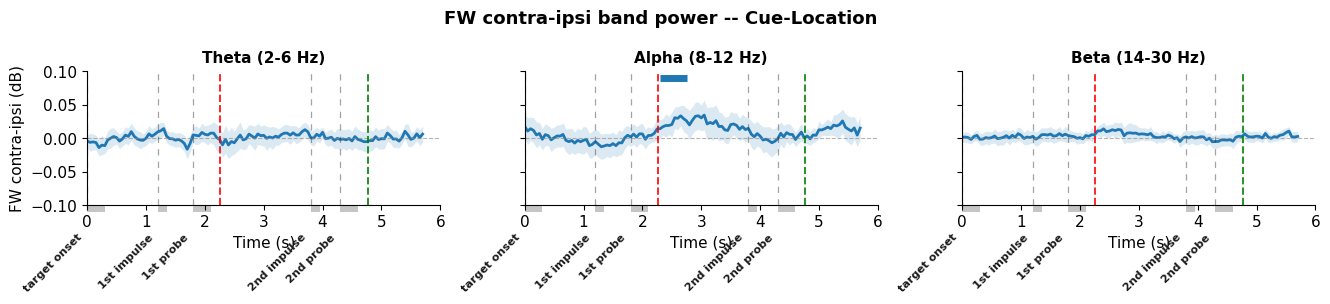

Cue-Location | bw | Theta (2-6 Hz):
No significant clusters found.
Cue-Location | bw | Alpha (8-12 Hz):
No significant clusters found.
Cue-Location | bw | Beta (14-30 Hz):
No significant clusters found.
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/bw_cue_band.png


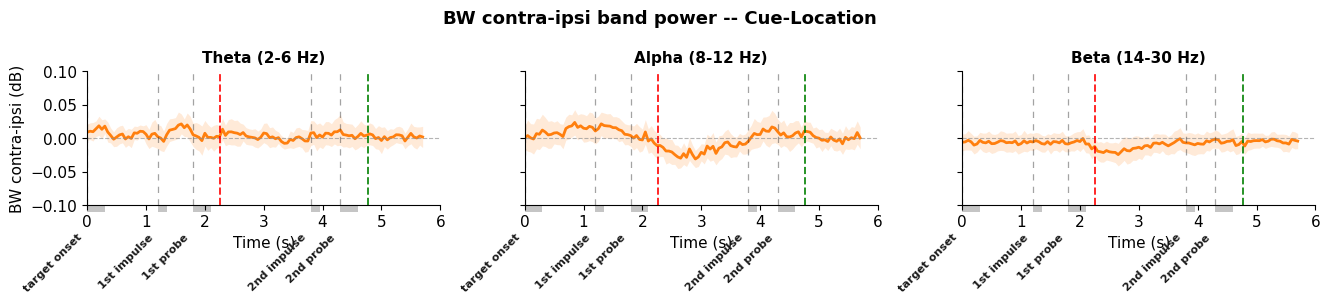

Cue-Location | ratio | Theta (2-6 Hz):
No significant clusters found.
Cue-Location | ratio | Alpha (8-12 Hz):
2.30-3.05s, p=0.0052 (significant)
Cue-Location | ratio | Beta (14-30 Hz):
2.20-2.70s, p=0.0088 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/ratio_cue_band.png


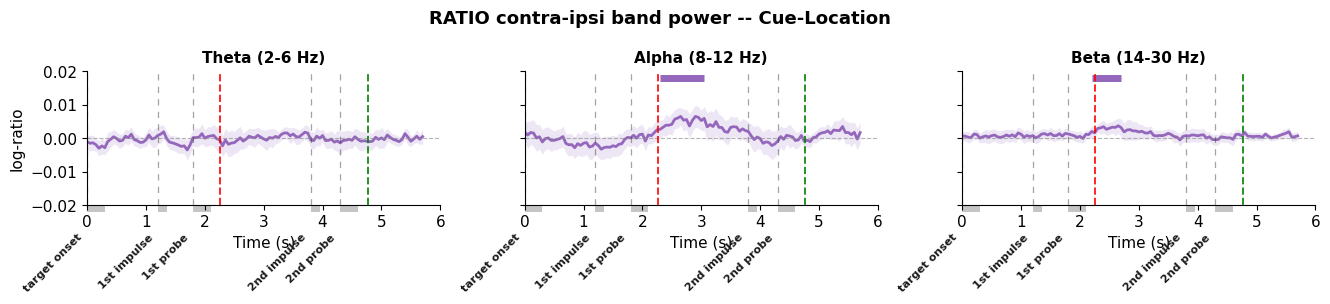

({'fw': {'figure': <Figure size 1350x330 with 3 Axes>,
   'axes': array([[<Axes: title={'center': 'Theta (2-6 Hz)'}, xlabel='Time (s)', ylabel='FW contra-ipsi (dB)'>,
           <Axes: title={'center': 'Alpha (8-12 Hz)'}, xlabel='Time (s)'>,
           <Axes: title={'center': 'Beta (14-30 Hz)'}, xlabel='Time (s)'>]],
         dtype=object),
   'clusters': {'fw': {'Theta (2-6 Hz)': [{'cluster_id': 1,
       'p': 0.5962,
       'start_idx': 26,
       'end_idx': 26,
       'significant': False},
      {'cluster_id': 2,
       'p': 0.779,
       'start_idx': 74,
       'end_idx': 74,
       'significant': False},
      {'cluster_id': 3,
       'p': 0.8388,
       'start_idx': 80,
       'end_idx': 80,
       'significant': False},
      {'cluster_id': 4,
       'p': 0.9452,
       'start_idx': 108,
       'end_idx': 108,
       'significant': False},
      {'cluster_id': 5,
       'p': 0.8286,
       'start_idx': 4,
       'end_idx': 4,
       'significant': False},
      {'cluster_id': 6

In [14]:
plot_band_timeseries(by_subj, subj_ids, mode='cue', baseline_correct=BL_CORRECT, bl0=-0.75, bl1=-0.25, t_stop=6, measure=['fw', 'bw', 'ratio'], split_measures=True, **LINE_KW)

In [15]:
# plot_band_timeseries(by_subj, subj_ids, mode='cue', baseline_correct=BL_CORRECT, bl0=-0.75, bl1=-0.25, t_stop=6,
#                      trial_filter='ipsi', measure=MEASURES, split_measures=True, **LINE_KW)

In [16]:
# plot_band_timeseries(by_subj, subj_ids, mode='cue', baseline_correct=BL_CORRECT, bl0=-0.75, bl1=-0.25, t_stop=6,
#                      trial_filter='contra', measure=MEASURES, split_measures=True, **LINE_KW)

Respond-Hand (early) | fw | Theta (2-6 Hz):
1.80-2.95s, p=0.0002 (significant)
Respond-Hand (early) | fw | Alpha (8-12 Hz):
4.30-4.65s, p=0.03 (significant)
Respond-Hand (early) | fw | Beta (14-30 Hz):
2.50-3.75s, p=0.0006 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/fw_early_hand_band.png


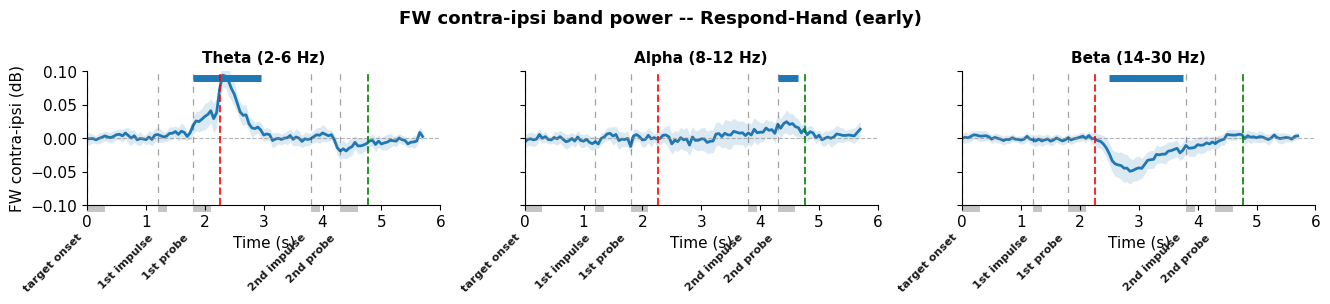

Respond-Hand (early) | bw | Theta (2-6 Hz):
2.20-2.75s, p=0.0002 (significant)
Respond-Hand (early) | bw | Alpha (8-12 Hz):
No significant clusters found.
Respond-Hand (early) | bw | Beta (14-30 Hz):
2.50-4.50s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/bw_early_hand_band.png


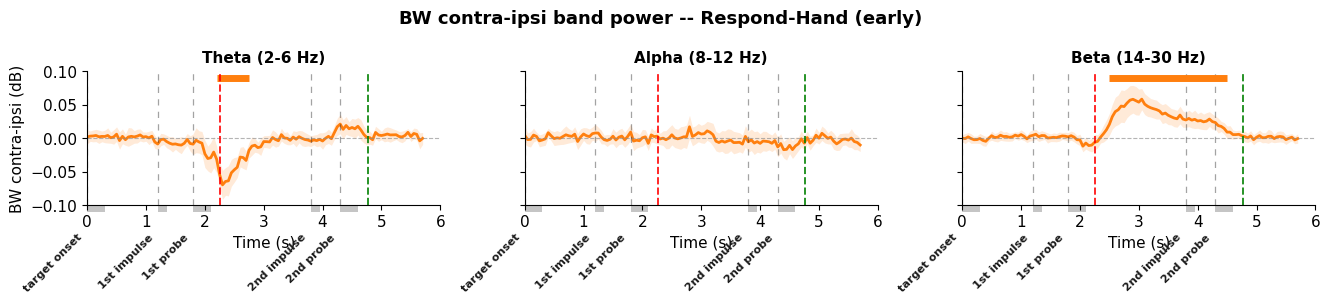

({'fw': {'figure': <Figure size 1350x330 with 3 Axes>,
   'axes': array([[<Axes: title={'center': 'Theta (2-6 Hz)'}, xlabel='Time (s)', ylabel='FW contra-ipsi (dB)'>,
           <Axes: title={'center': 'Alpha (8-12 Hz)'}, xlabel='Time (s)'>,
           <Axes: title={'center': 'Beta (14-30 Hz)'}, xlabel='Time (s)'>]],
         dtype=object),
   'clusters': {'fw': {'Theta (2-6 Hz)': [{'cluster_id': 1,
       'p': 0.9748,
       'start_idx': 13,
       'end_idx': 13,
       'significant': False},
      {'cluster_id': 2,
       'p': 0.8324,
       'start_idx': 30,
       'end_idx': 30,
       'significant': False},
      {'cluster_id': 3,
       'p': 0.0002,
       'start_idx': 36,
       'end_idx': 59,
       'significant': True},
      {'cluster_id': 4,
       'p': 0.9248,
       'start_idx': 113,
       'end_idx': 113,
       'significant': False},
      {'cluster_id': 5,
       'p': 0.0568,
       'start_idx': 85,
       'end_idx': 89,
       'significant': False},
      {'cluster_id':

In [17]:
plot_band_timeseries(by_subj, subj_ids, mode='hand', rt_type='early', baseline_correct=BL_CORRECT, bl0=-0.75, bl1=-0.25, t_stop=6, measure=MEASURES, 
                     split_measures=True, exclude_invalid_rt=RT_REMOVE, **LINE_KW)

Respond-Hand (late) | fw | Theta (2-6 Hz):
4.70-5.40s, p=0.0004 (significant)
2.40-2.65s, p=0.0392 (significant)
Respond-Hand (late) | fw | Alpha (8-12 Hz):
No significant clusters found.
Respond-Hand (late) | fw | Beta (14-30 Hz):
4.95-5.70s, p=0.0002 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/fw_late_hand_band.png


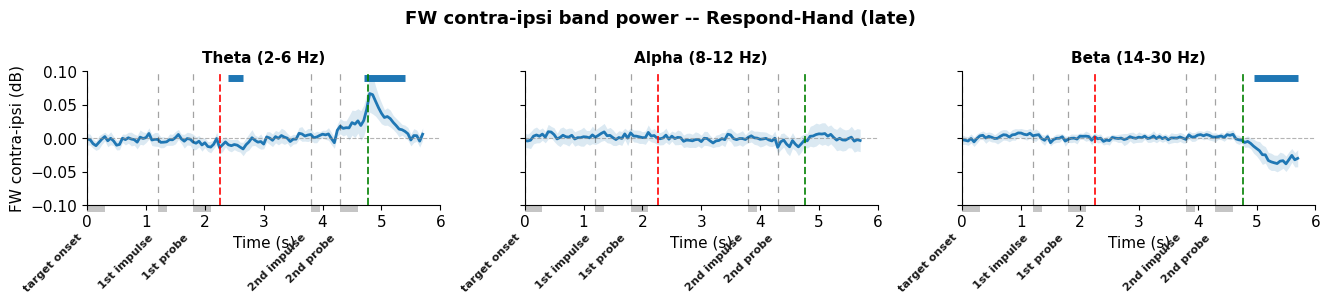

Respond-Hand (late) | bw | Theta (2-6 Hz):
5.05-5.35s, p=0.012 (significant)
Respond-Hand (late) | bw | Alpha (8-12 Hz):
No significant clusters found.
Respond-Hand (late) | bw | Beta (14-30 Hz):
5.00-5.70s, p=0.0002 (significant)
4.50-4.75s, p=0.0354 (significant)
[saved] /home/dilay/project2/tw/results/figs/micheal/no-bl/all/bw_late_hand_band.png


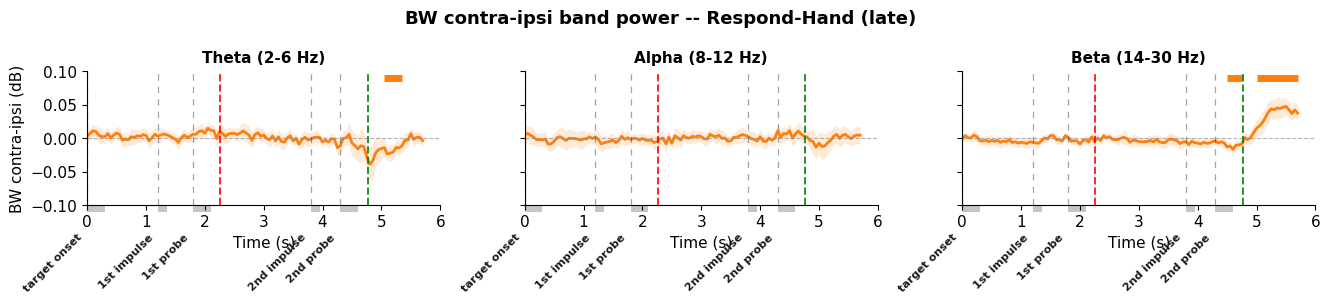

({'fw': {'figure': <Figure size 1350x330 with 3 Axes>,
   'axes': array([[<Axes: title={'center': 'Theta (2-6 Hz)'}, xlabel='Time (s)', ylabel='FW contra-ipsi (dB)'>,
           <Axes: title={'center': 'Alpha (8-12 Hz)'}, xlabel='Time (s)'>,
           <Axes: title={'center': 'Beta (14-30 Hz)'}, xlabel='Time (s)'>]],
         dtype=object),
   'clusters': {'fw': {'Theta (2-6 Hz)': [{'cluster_id': 1,
       'p': 0.9716,
       'start_idx': 80,
       'end_idx': 80,
       'significant': False},
      {'cluster_id': 2,
       'p': 0.0722,
       'start_idx': 85,
       'end_idx': 88,
       'significant': False},
      {'cluster_id': 3,
       'p': 0.1804,
       'start_idx': 90,
       'end_idx': 92,
       'significant': False},
      {'cluster_id': 4,
       'p': 0.0004,
       'start_idx': 94,
       'end_idx': 108,
       'significant': True},
      {'cluster_id': 5,
       'p': 0.3068,
       'start_idx': 2,
       'end_idx': 3,
       'significant': False},
      {'cluster_id': 6,

In [18]:
plot_band_timeseries(by_subj, subj_ids, mode='hand', rt_type='late', 
                     baseline_correct=BL_CORRECT, bl0=-0.75, bl1=-0.25, t_stop=6, 
                     measure=MEASURES, split_measures=True,
                     exclude_invalid_rt=RT_REMOVE, **LINE_KW)

## All Lines Average

Cue-Location | fw | Theta (2-6 Hz):
0.00-5.70s, p=0.0002 (significant)
Cue-Location | fw | Alpha (8-12 Hz):
0.00-1.00s, p=0.0258 (significant)
1.10-2.70s, p=0.0096 (significant)
3.70-4.95s, p=0.0152 (significant)
Cue-Location | fw | Beta (14-30 Hz):
0.00-5.70s, p=0.0002 (significant)


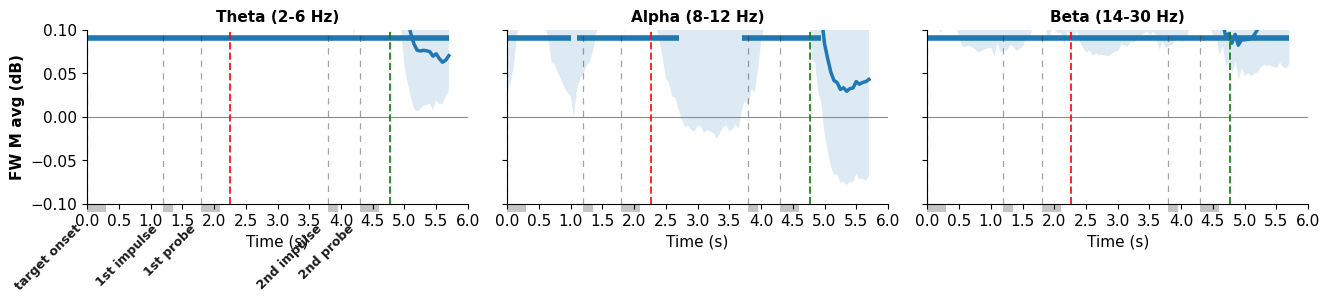

Cue-Location | bw | Theta (2-6 Hz):
2.80-3.60s, p=0.011 (significant)
4.50-4.90s, p=0.049 (significant)
Cue-Location | bw | Alpha (8-12 Hz):
2.95-3.80s, p=0.0472 (significant)
4.90-5.70s, p=0.0192 (significant)
Cue-Location | bw | Beta (14-30 Hz):
0.00-5.70s, p=0.0002 (significant)


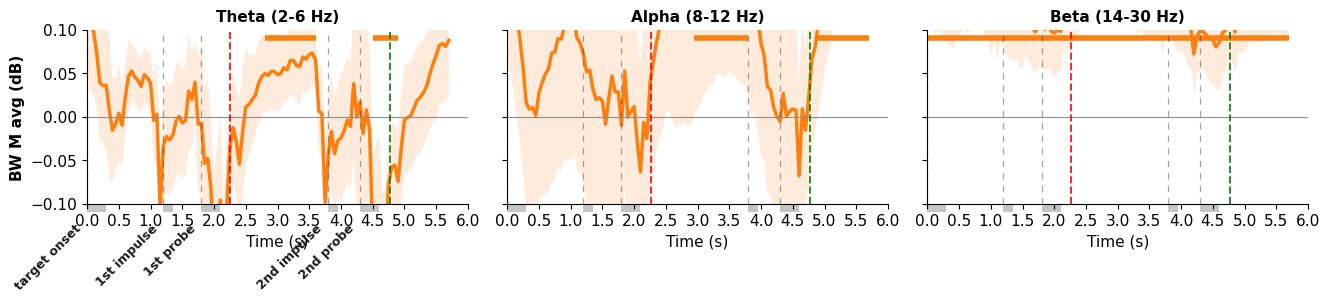

In [19]:
plot_all_lines_measures(by_subj, subj_ids, baseline_correct=BL_CORRECT, 
                        measure=MEASURES,
                         bl0=-0.75, bl1=-0.25, mode='cue',
                         line_idx = MID_LINES, exclude_invalid_rt=RT_REMOVE)